2026-09-15 21:56:19.406 | INFO     | __main__:node_a:12 - cur_step: 1, node_a 被触发
2026-09-15 21:56:19.408 | INFO     | __main__:node_b:17 - cur_step: 2, node_b 被触发
2026-09-15 21:56:19.409 | INFO     | __main__:node_c:22 - cur_step: 2, node_c 被触发
2026-09-15 21:56:19.411 | INFO     | __main__:node_d:27 - cur_step: 3, node_d 被触发
2026-09-15 21:56:19.411 | INFO     | __main__:node_e:32 - cur_step: 3, node_e 被触发
2026-09-15 21:56:19.412 | INFO     | __main__:node_e:32 - cur_step: 4, node_e 被触发


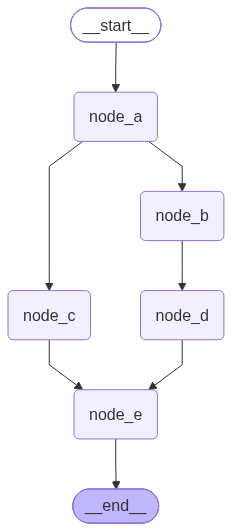

In [4]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_core.runnables import RunnableConfig

from loguru import logger

class EmptyState(TypedDict):
    pass

def node_a(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info("cur_step: {}, node_a 被触发", cur_step)
    return {}

def node_b(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info("cur_step: {}, node_b 被触发", cur_step)
    return {}

def node_c(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info("cur_step: {}, node_c 被触发", cur_step)
    return {}

def node_d(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info("cur_step: {}, node_d 被触发", cur_step)
    return {}

def node_e(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info("cur_step: {}, node_e 被触发", cur_step)
    return {}

builder = StateGraph(state_schema=EmptyState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_node("node_d", node_d)
builder.add_node("node_e", node_e)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_a", "node_c")
builder.add_edge("node_b", "node_d")
builder.add_edge("node_d", "node_e")
builder.add_edge("node_c", "node_e")



# builder.add_edge(["node_c", "node_d"], "node_e")

graph = builder.compile()
graph.invoke({})

from IPython.display import display
display(graph)

2026-09-15 22:07:57.370 | INFO     | __main__:reducer_node:45 - reducer entries: [('hello', 1), ('world', 1), ('hello', 1), ('Atguigu', 1), ('hello', 1), ('LLM', 1)]
2026-09-15 22:07:57.371 | INFO     | __main__:reducer_node:55 - reducer shuffle entries: {'hello': [1, 1, 1], 'world': [1], 'Atguigu': [1], 'LLM': [1]}


{'input_values': ['hello world', 'hello Atguigu', 'hello LLM'], 'entries': [('hello', 1), ('world', 1), ('hello', 1), ('Atguigu', 1), ('hello', 1), ('LLM', 1)], 'word_counts': {'hello': 3, 'world': 1, 'Atguigu': 1, 'LLM': 1}}


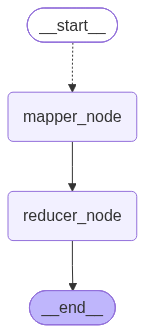

In [ ]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from _collections_abc import Sequence
from operator import add

from loguru import logger

class OverAllState(TypedDict):
    input_values: list[str]
    entries: Annotated[list[tuple[str, int]], add]
    word_counts: dict[str, int]

def router_map(state: OverAllState) -> Sequence[Send]:
    input_values = state["input_values"]

    tasks = []
    for input_value in input_values:
        tasks.append(
            Send(
                "mapper_node",
                {"input_value": input_value}
            )
        )

    return tasks

class MaperInputState(TypedDict):
    input_value: str

def mapper_node(state: MaperInputState) -> OverAllState:
    input_value = state["input_value"]
    words = input_value.split(" ")
    entries = []

    for word in words:
        entries.append((word, 1))

    return {
        "entries": entries
    }

def reducer_node(state: OverAllState) -> OverAllState:
    entries = state["entries"]
    logger.info("reducer entries: {}", entries)

    shuffle_dict = {}

    for k, v in entries:
        if k not in shuffle_dict:
            shuffle_dict[k] = [v]
        else:
            shuffle_dict[k].append(v)

    logger.info("reducer shuffle entries: {}", shuffle_dict)

    reduce_dict = {}

    for k, v in shuffle_dict.items():
        reduce_dict[k] = sum(v)

    return {
        "word_counts": reduce_dict
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("mapper_node", mapper_node)
builder.add_node("reducer_node", reducer_node)

builder.add_conditional_edges(START, router_map, path_map=["mapper_node"])
builder.add_edge("mapper_node", "reducer_node")
builder.add_edge("reducer_node", END)

graph = builder.compile()
word_counts = graph.invoke(
    {"input_values": [
        "hello world",
        "hello Atguigu",
        "hello LLM"
    ]}
)

print(word_counts)

from IPython.display import display
display(graph)